In [33]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.linear_model import Perceptron
import tensorflow
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.utils import to_categorical
import warnings
warnings.filterwarnings('ignore')

In [34]:
df = pd.read_csv('bank-additional-full-comma.csv')

In [35]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='str')

In [36]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [37]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='str')

In [38]:
df['job'].value_counts()

job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

In [39]:
df['marital'].value_counts()

marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

In [40]:
df['marital'] = df['marital'].replace('unknown', 'married')

In [41]:
df['marital'].value_counts()

marital
married     25008
single      11568
divorced     4612
Name: count, dtype: int64

In [42]:
df['education'].value_counts()

education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

In [43]:
# Get existing values excluding 'unknown'
education_values = df.loc[df['education'] != 'unknown', 'education']

# Replace 'unknown' randomly
df.loc[df['education'] == 'unknown', 'education'] = np.random.choice(
    education_values,
    size=(df['education'] == 'unknown').sum(),
    replace=True
)

In [44]:
df['education'].value_counts()

education
university.degree      12672
high.school             9936
basic.9y                6326
professional.course     5475
basic.4y                4354
basic.6y                2407
illiterate                18
Name: count, dtype: int64

In [45]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='str')

In [46]:
df['default'].value_counts()

default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

In [47]:
df['default'] = df['default'].replace('unknown','no')

In [48]:
df['default'].value_counts()

default
no     41185
yes        3
Name: count, dtype: int64

In [49]:
df['housing'].value_counts()

housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

In [50]:
# Get existing values excluding 'unknown'
housing_values = df.loc[df['housing'] != 'unknown', 'housing']

# Replace 'unknown' randomly
df.loc[df['housing'] == 'unknown', 'housing'] = np.random.choice(
    housing_values,
    size=(df['housing'] == 'unknown').sum(),
    replace=True
)

In [51]:
df['housing'].value_counts()

housing
yes    22119
no     19069
Name: count, dtype: int64

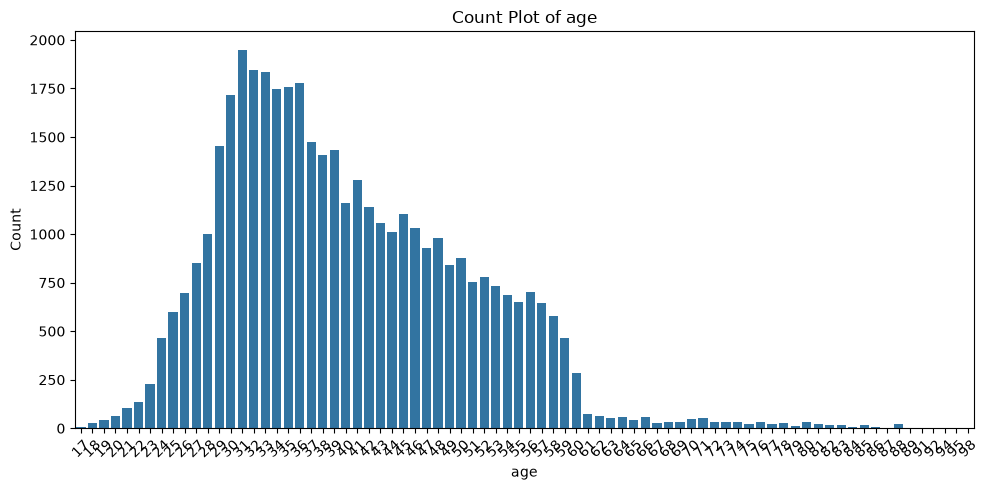

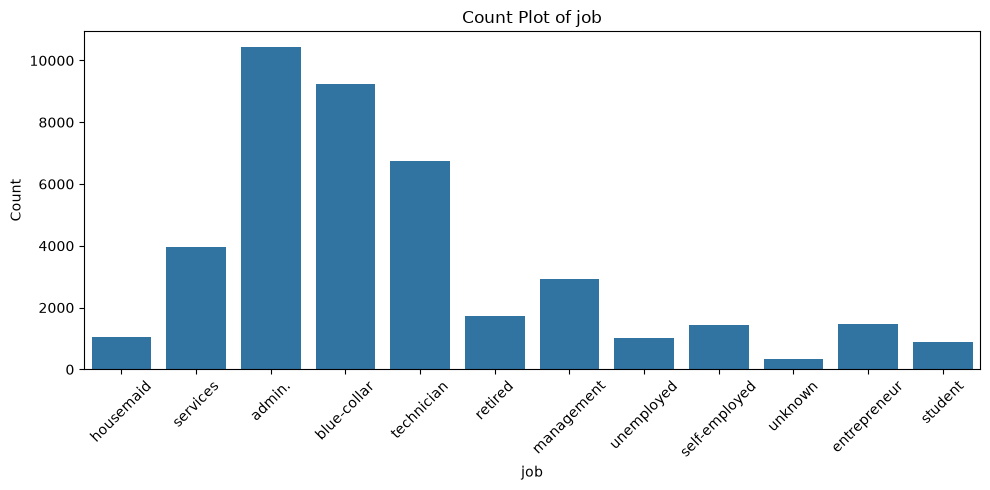

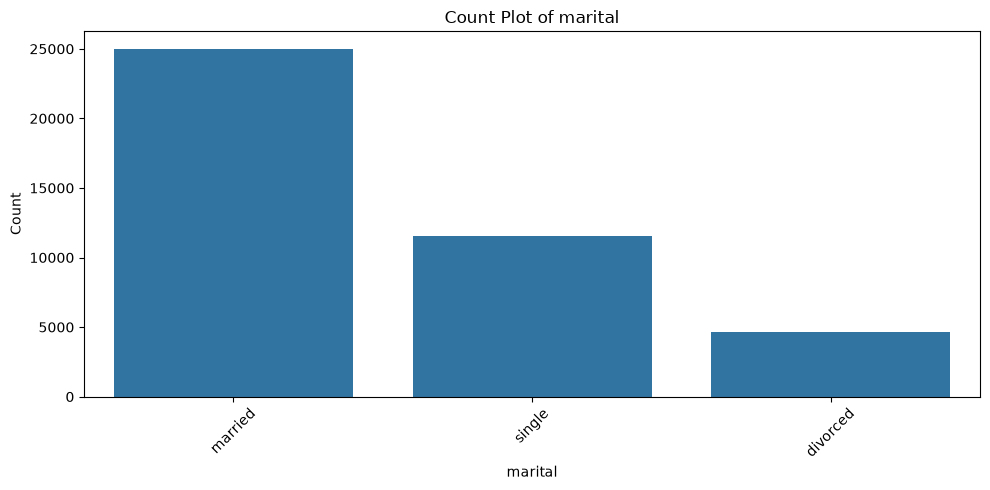

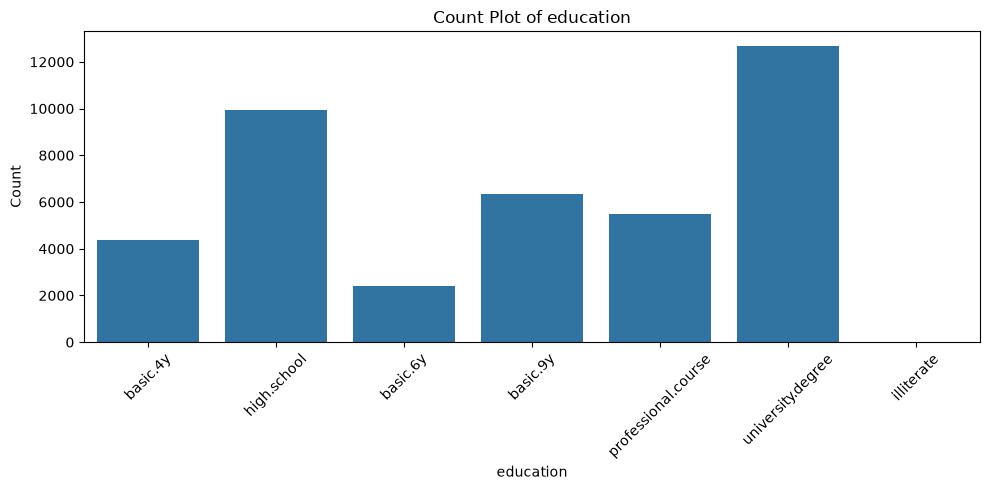

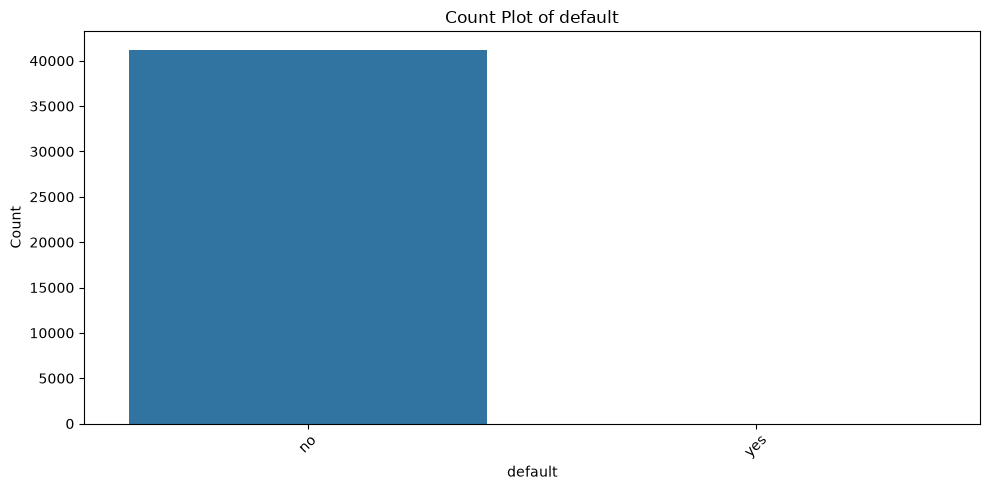

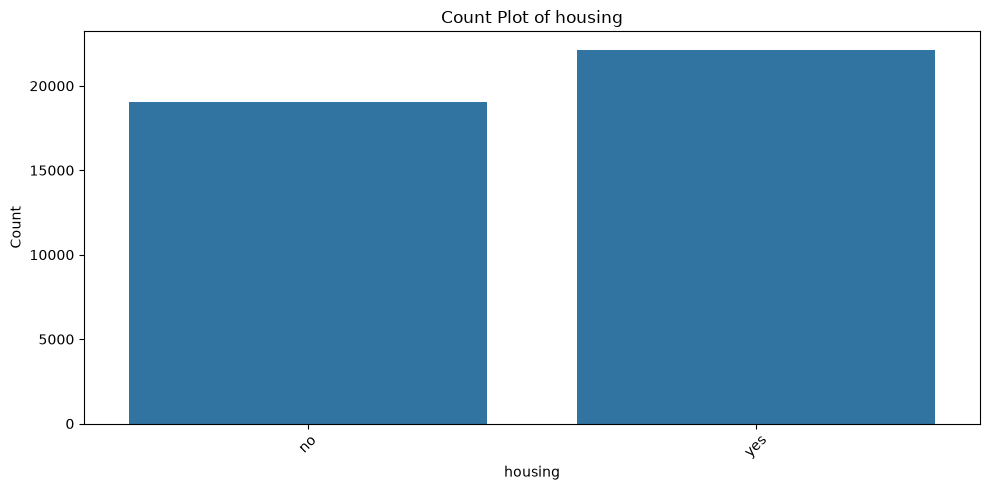

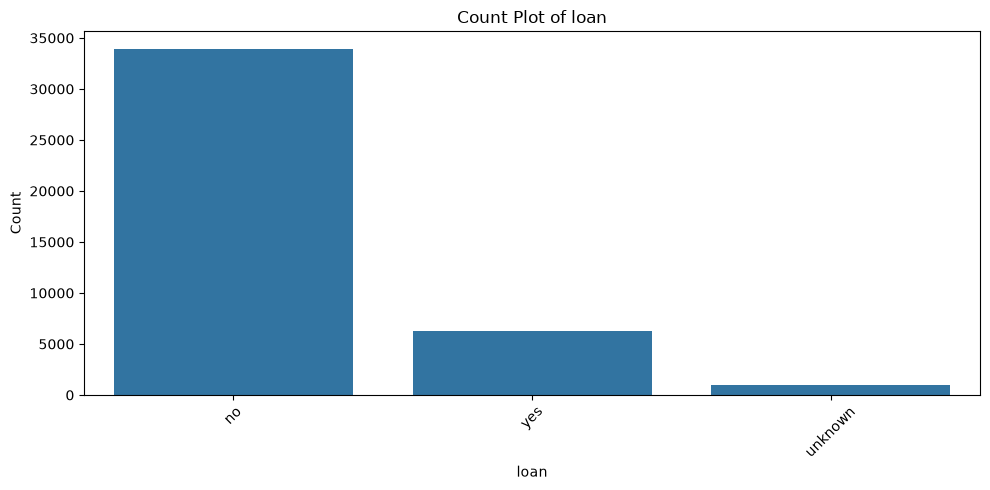

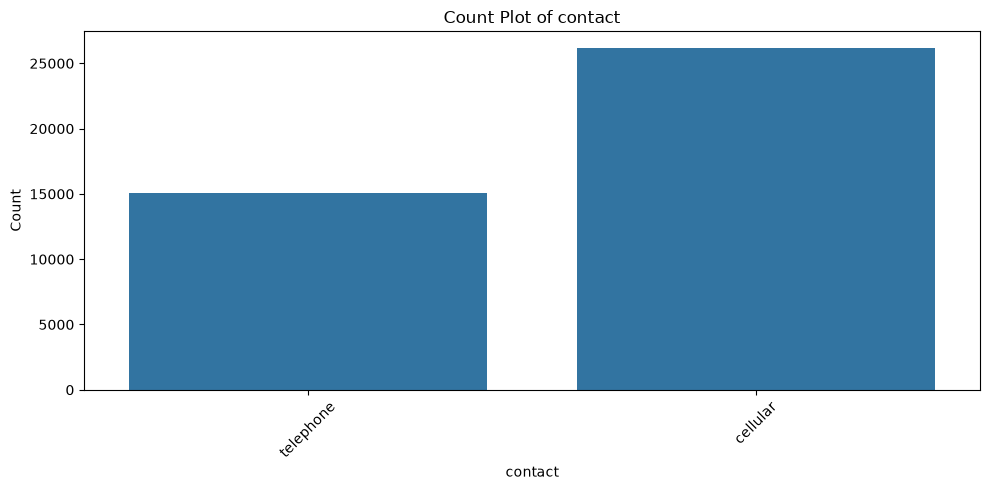

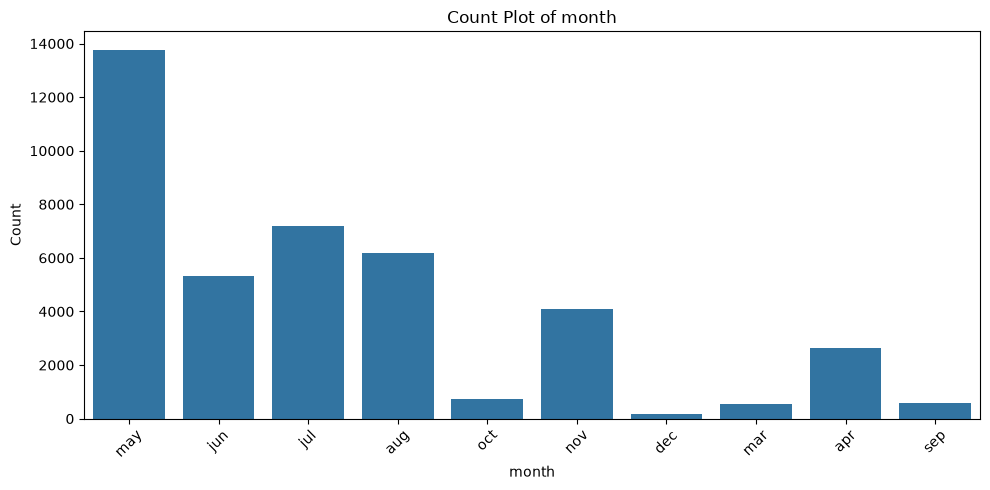

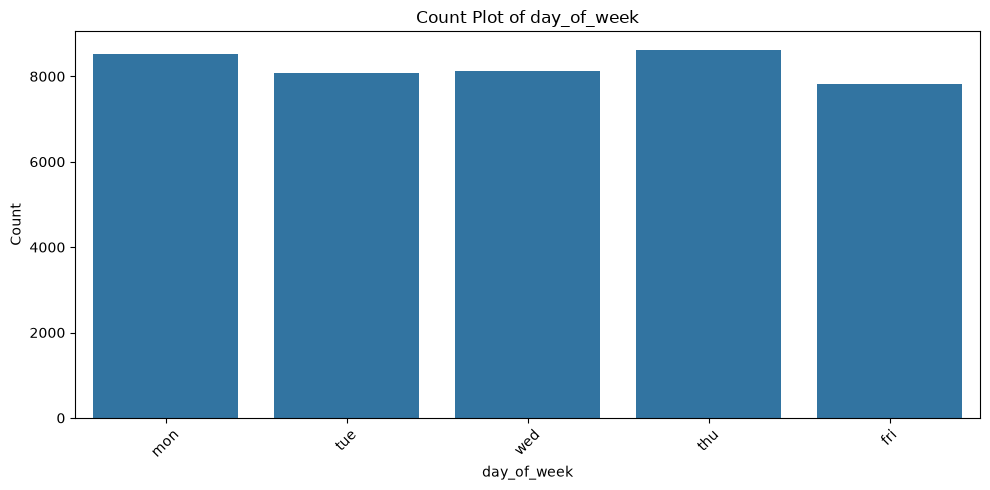

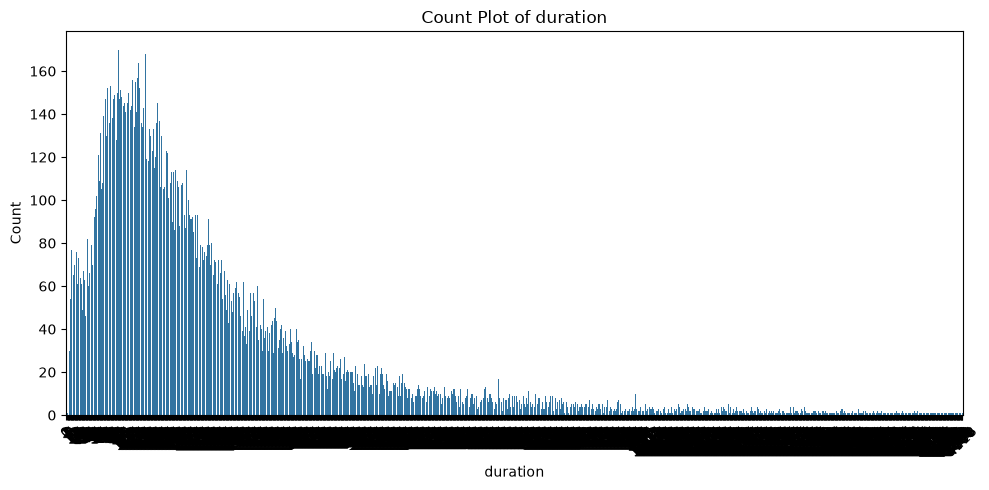

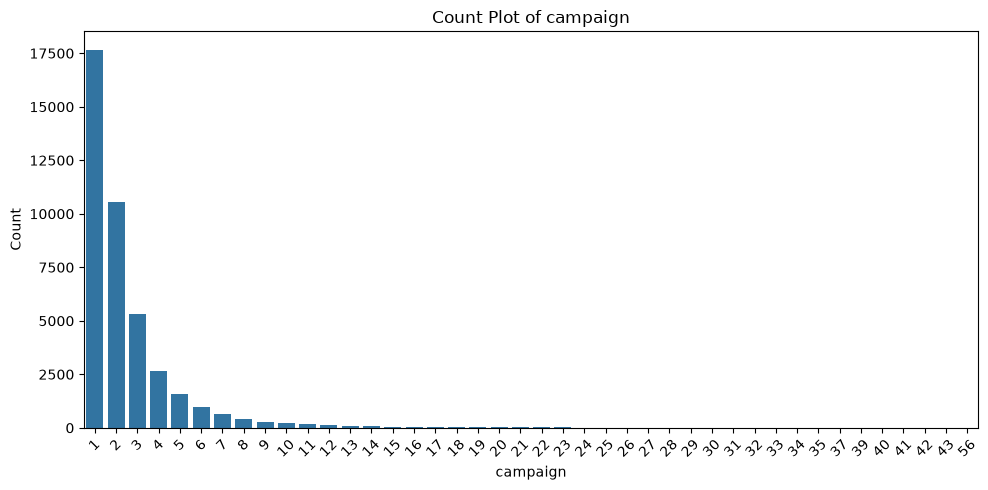

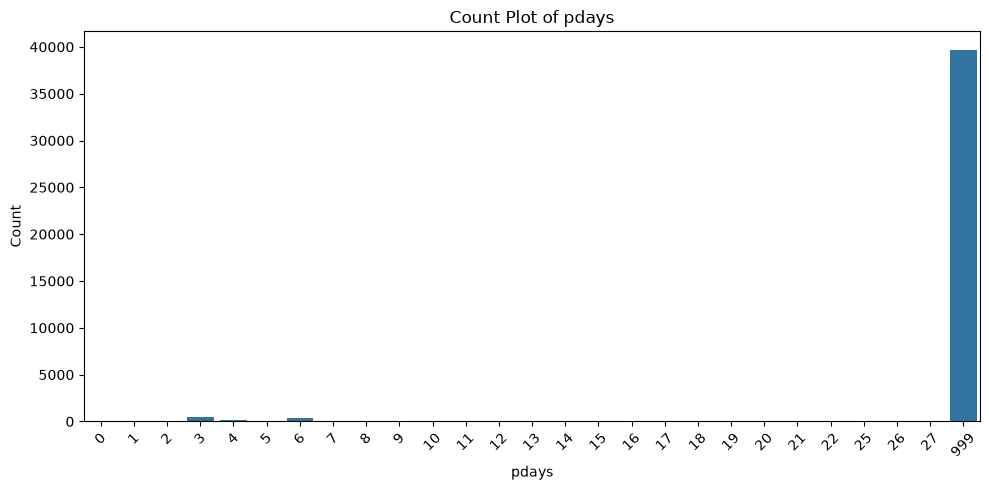

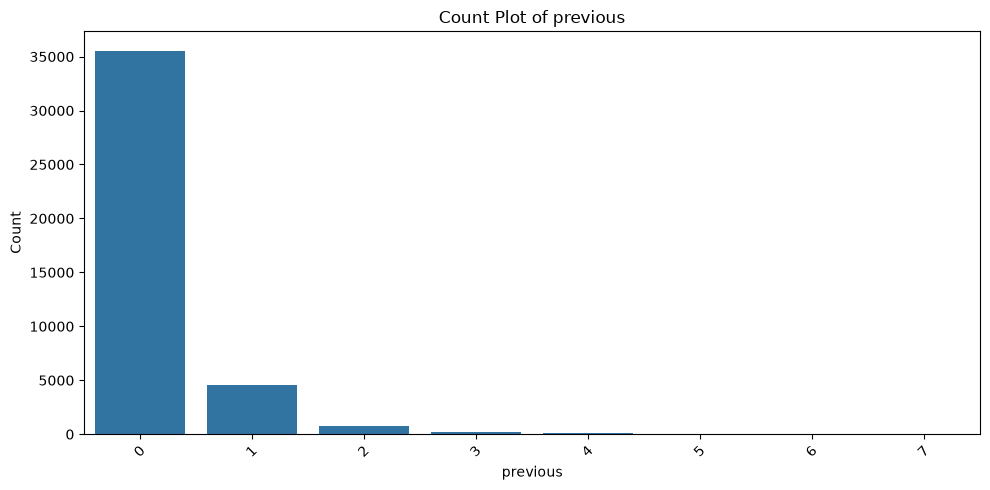

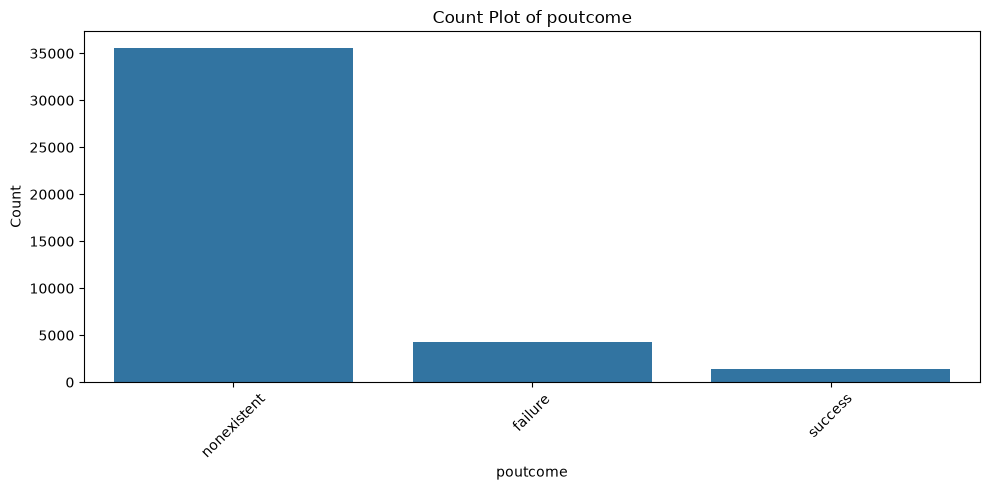

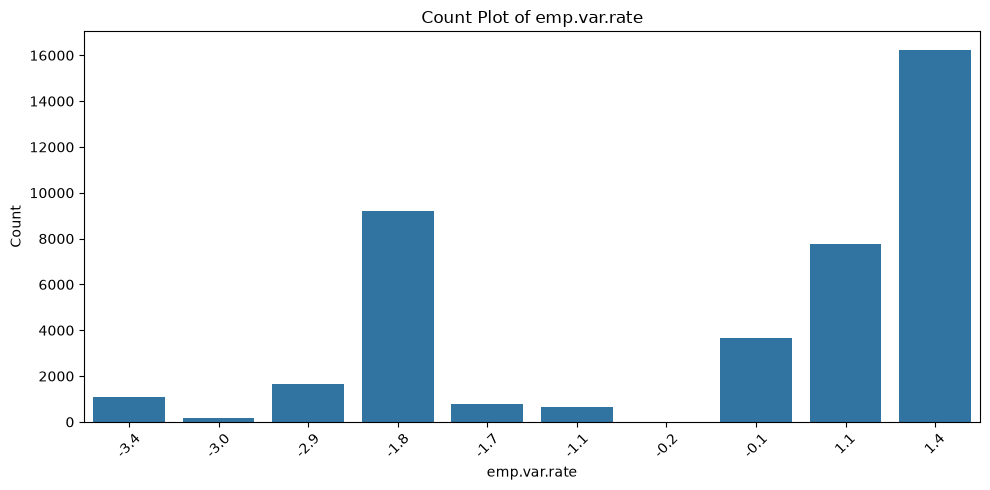

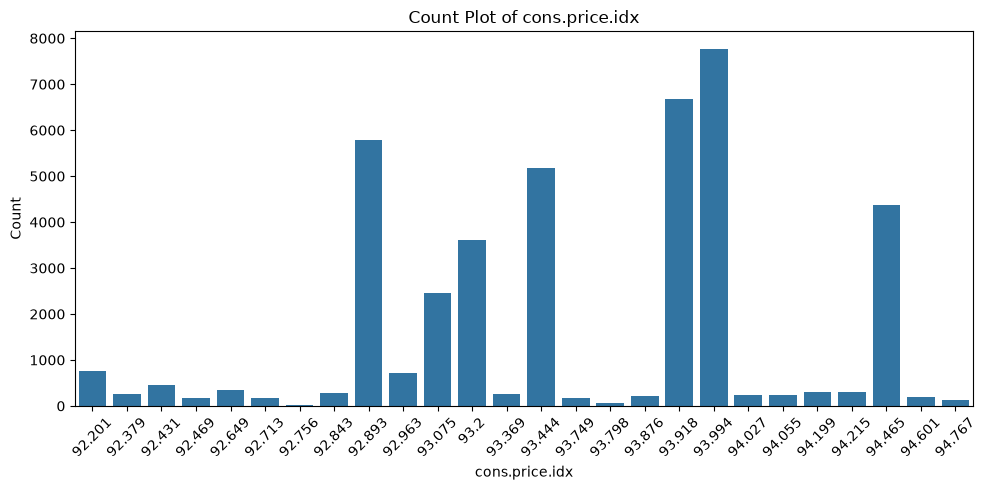

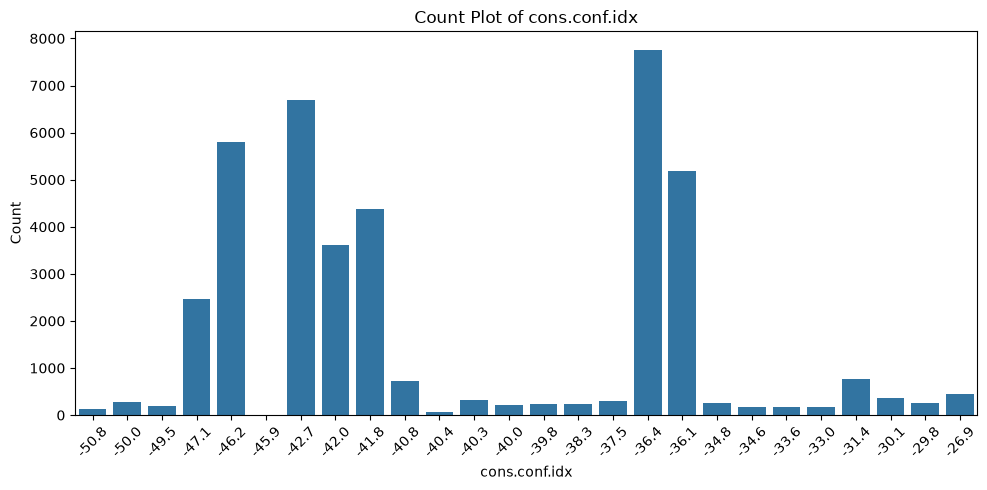

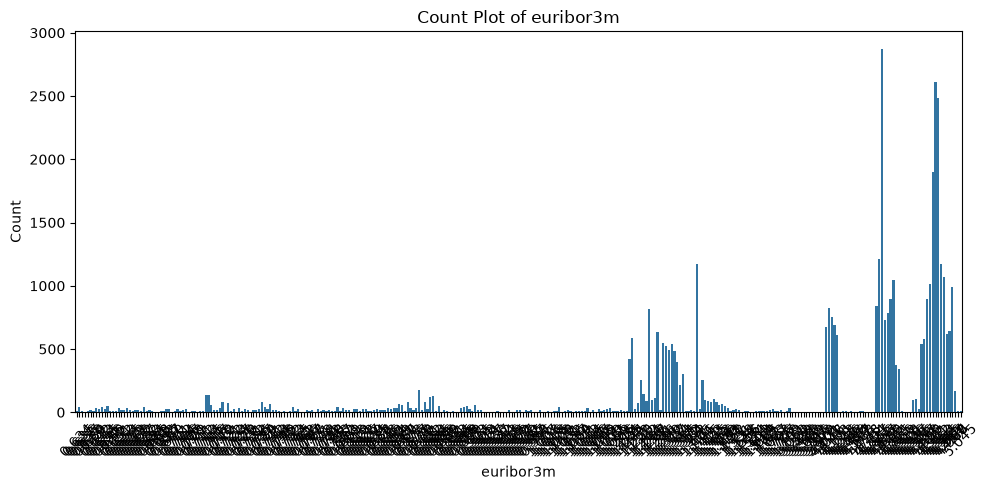

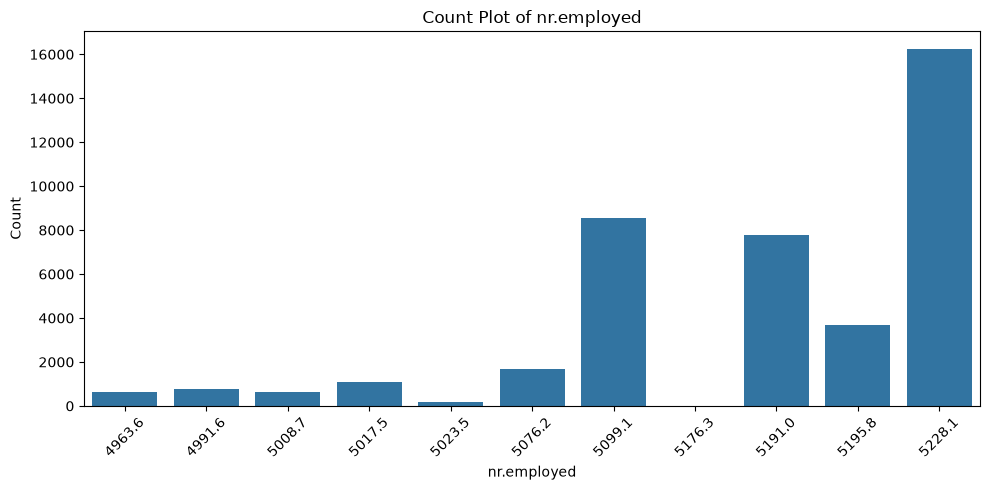

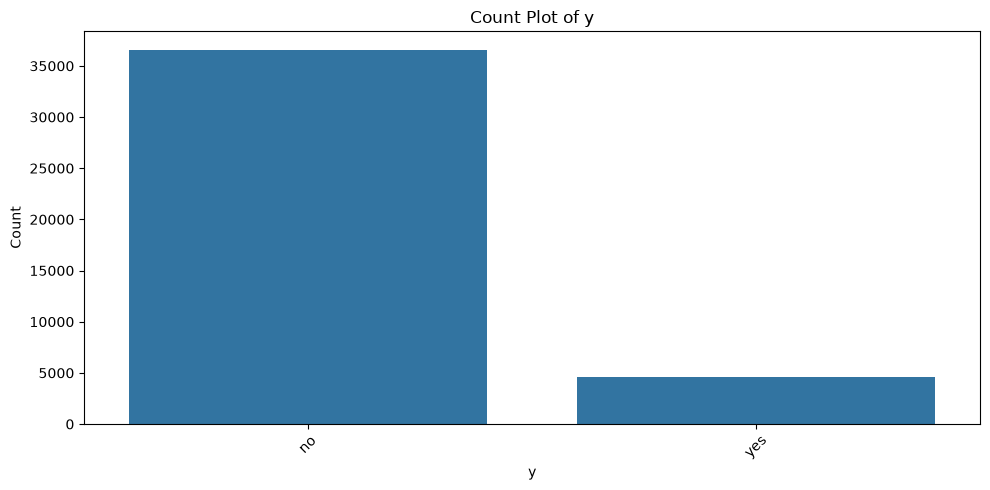

In [52]:
columns = [
    'age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
    'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
    'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
    'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'
]

for col in columns:
    plt.figure(figsize=(10, 5))

    sns.countplot(data=df, x=col)

    plt.title(f'Count Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

In [53]:
df = df.drop(['default','pdays'],axis =1)

In [54]:
df.columns

Index(['age', 'job', 'marital', 'education', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'duration', 'campaign', 'previous', 'poutcome',
       'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m',
       'nr.employed', 'y'],
      dtype='str')

In [55]:
df['loan'].value_counts()

loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64

In [56]:
# Get existing values excluding 'unknown'
loan_values = df.loc[df['loan'] != 'unknown', 'loan']

# Replace 'unknown' randomly
df.loc[df['loan'] == 'unknown', 'loan'] = np.random.choice(
    loan_values,
    size=(df['loan'] == 'unknown').sum(),
    replace=True
)

In [57]:
df['loan'].value_counts()

loan
no     34801
yes     6387
Name: count, dtype: int64

<Axes: xlabel='education', ylabel='count'>

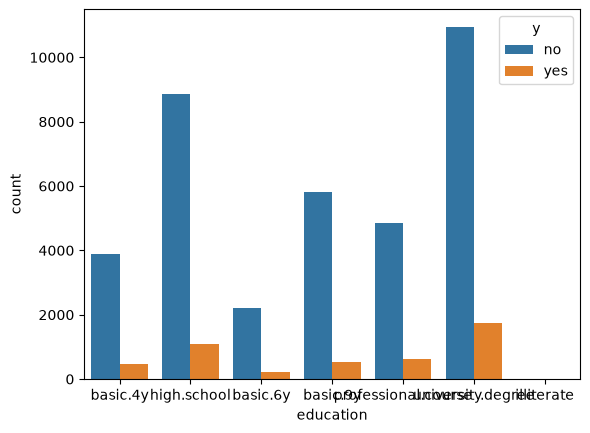

In [58]:
sns.countplot(x=df['education'],hue=df['y'])

In [59]:
df.head()

,age,job,marital,education,housing,loan,contact,month,day_of_week,duration,campaign,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,telephone,may,mon,261,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,no,no,telephone,may,mon,149,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,yes,no,telephone,may,mon,226,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,telephone,may,mon,151,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,yes,telephone,may,mon,307,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [60]:
df.shape

(41188, 19)

In [63]:
df.columns

Index(['age', 'job', 'marital', 'education', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'duration', 'campaign', 'previous', 'poutcome',
       'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m',
       'nr.employed', 'y'],
      dtype='str')

In [65]:
x= df.drop(['y'],axis=1)
a =df['y']

In [66]:
encode = LabelEncoder()

In [68]:
x.columns

Index(['age', 'job', 'marital', 'education', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'duration', 'campaign', 'previous', 'poutcome',
       'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m',
       'nr.employed'],
      dtype='str')

In [86]:
x

,age,job,marital,education,housing,loan,contact,month,day_of_week,duration,campaign,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56,housemaid,married,basic.4y,no,no,telephone,may,mon,261,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
1,57,services,married,high.school,no,no,telephone,may,mon,149,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
2,37,services,married,high.school,yes,no,telephone,may,mon,226,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
3,40,admin.,married,basic.6y,no,no,telephone,may,mon,151,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
4,56,services,married,high.school,no,yes,telephone,may,mon,307,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,yes,no,cellular,nov,fri,334,1,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6
41184,46,blue-collar,married,professional.course,no,no,cellular,nov,fri,383,1,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6
41185,56,retired,married,university.degree,yes,no,cellular,nov,fri,189,2,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6
41186,44,technician,married,professional.course,no,no,cellular,nov,fri,442,1,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6


In [87]:
encoded_x = pd.get_dummies(
    x,
    columns=['job', 'marital', 'education', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome',
       ],
    drop_first=True
)


In [88]:
encoded_x

,age,duration,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_blue-collar,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,261,1,0,1.1,93.994,-36.4,4.857,5191.0,False,...,True,False,False,False,True,False,False,False,True,False
1,57,149,1,0,1.1,93.994,-36.4,4.857,5191.0,False,...,True,False,False,False,True,False,False,False,True,False
2,37,226,1,0,1.1,93.994,-36.4,4.857,5191.0,False,...,True,False,False,False,True,False,False,False,True,False
3,40,151,1,0,1.1,93.994,-36.4,4.857,5191.0,False,...,True,False,False,False,True,False,False,False,True,False
4,56,307,1,0,1.1,93.994,-36.4,4.857,5191.0,False,...,True,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,334,1,0,-1.1,94.767,-50.8,1.028,4963.6,False,...,False,True,False,False,False,False,False,False,True,False
41184,46,383,1,0,-1.1,94.767,-50.8,1.028,4963.6,True,...,False,True,False,False,False,False,False,False,True,False
41185,56,189,2,0,-1.1,94.767,-50.8,1.028,4963.6,False,...,False,True,False,False,False,False,False,False,True,False
41186,44,442,1,0,-1.1,94.767,-50.8,1.028,4963.6,False,...,False,True,False,False,False,False,False,False,True,False


In [89]:
encoded_x=encoded_x.astype(int)

In [90]:
encoded_x

,age,duration,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_blue-collar,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,261,1,0,1,93,-36,4,5191,0,...,1,0,0,0,1,0,0,0,1,0
1,57,149,1,0,1,93,-36,4,5191,0,...,1,0,0,0,1,0,0,0,1,0
2,37,226,1,0,1,93,-36,4,5191,0,...,1,0,0,0,1,0,0,0,1,0
3,40,151,1,0,1,93,-36,4,5191,0,...,1,0,0,0,1,0,0,0,1,0
4,56,307,1,0,1,93,-36,4,5191,0,...,1,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,334,1,0,-1,94,-50,1,4963,0,...,0,1,0,0,0,0,0,0,1,0
41184,46,383,1,0,-1,94,-50,1,4963,1,...,0,1,0,0,0,0,0,0,1,0
41185,56,189,2,0,-1,94,-50,1,4963,0,...,0,1,0,0,0,0,0,0,1,0
41186,44,442,1,0,-1,94,-50,1,4963,0,...,0,1,0,0,0,0,0,0,1,0


In [77]:
a

0         no
1         no
2         no
3         no
4         no
        ... 
41183    yes
41184     no
41185     no
41186    yes
41187     no
Name: y, Length: 41188, dtype: str

In [91]:
y_encode= encode.fit_transform(a)

In [94]:
encoded_x.shape

(41188, 46)

In [92]:
X_train, X_test, y_train, y_test = train_test_split(encoded_x, y_encode, test_size=0.33, random_state=42)

In [95]:
Perceptron_model = Perceptron(max_iter=10000,random_state=42)

In [96]:
Perceptron_model.fit(X_train,y_train)

,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",10000
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None


In [97]:
y_predict_per = Perceptron_model.predict(X_test)

In [98]:
accuracy =accuracy_score(y_test,y_predict_per)

In [99]:
accuracy

0.8906054586919738

In [100]:
print(classification_report(y_test,y_predict_per))

              precision    recall  f1-score   support

           0       0.90      0.99      0.94     12056
           1       0.59      0.11      0.18      1537

    accuracy                           0.89     13593
   macro avg       0.74      0.55      0.56     13593
weighted avg       0.86      0.89      0.86     13593



In [101]:
confusion_matrix(y_test,y_predict_per)

array([[11941,   115],
       [ 1372,   165]])

In [110]:
model_seq = Sequential([
    Dense(128,input_dim = 46,activation='relu'),
    Dense(64,activation='relu'),
    Dense(1,activation='sigmoid')
])

In [111]:
model_seq.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [112]:
history=model_seq.fit(X_train,y_train,epochs=100,batch_size=10,validation_split=0.2,verbose=1)

Epoch 1/100
2208/2208 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8483 - loss: 5.1817 - val_accuracy: 0.8875 - val_loss: 1.7573
Epoch 2/100
2208/2208 ━━━━━━━━━━━━━━━━━━━━ 2s 919us/step - accuracy: 0.8610 - loss: 2.0798 - val_accuracy: 0.9023 - val_loss: 0.4733
Epoch 3/100
2208/2208 ━━━━━━━━━━━━━━━━━━━━ 2s 924us/step - accuracy: 0.8733 - loss: 1.0202 - val_accuracy: 0.8366 - val_loss: 0.4819
Epoch 4/100
2208/2208 ━━━━━━━━━━━━━━━━━━━━ 2s 914us/step - accuracy: 0.8775 - loss: 0.6452 - val_accuracy: 0.8782 - val_loss: 0.3045
Epoch 5/100
2208/2208 ━━━━━━━━━━━━━━━━━━━━ 2s 930us/step - accuracy: 0.8825 - loss: 0.4428 - val_accuracy: 0.8998 - val_loss: 0.2217
Epoch 6/100
2208/2208 ━━━━━━━━━━━━━━━━━━━━ 2s 915us/step - accuracy: 0.8892 - loss: 0.3131 - val_accuracy: 0.8993 - val_loss: 0.2179
Epoch 7/100
2208/2208 ━━━━━━━━━━━━━━━━━━━━ 2s 928us/step - accuracy: 0.8966 - loss: 0.2626 - val_accuracy: 0.8967 - val_loss: 0.2196
Epoch 8/100
2208/2208 ━━━━━━━━━━━━━━━━━━━━ 2s 926us/step - accuracy: 0.

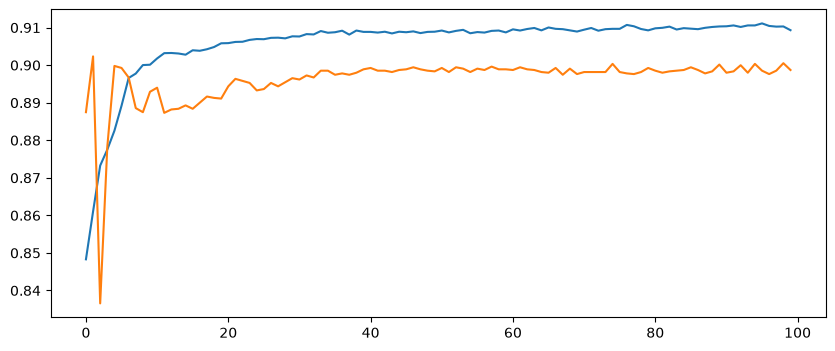

In [122]:
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
